In [1]:
from fastai.vision.all import *
import timm

In [2]:
path = untar_data(URLs.PETS)/'images'

dls = ImageDataLoaders.from_name_func(
    '.',
    get_image_files(path),
    valid_pct = 0.2,
    seed = 42,
    label_func = RegexLabeller(pat = r'^([^/]+)_\d+'),
    item_tfms = Resize(224)
)

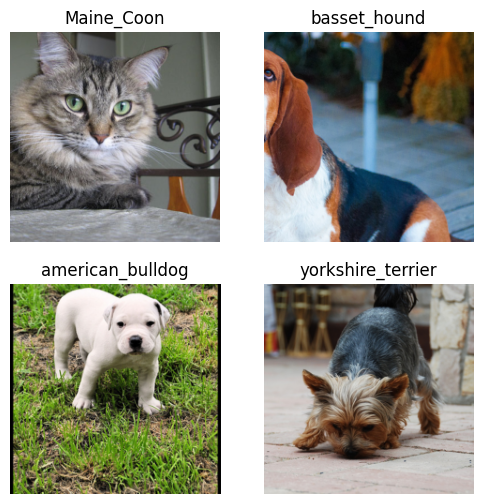

In [3]:
dls.show_batch(max_n = 4)

In [ ]:
learn = vision_learner(dls, resnet34, metrics = error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.550018,0.311513,0.095399,25:14


epoch,train_loss,valid_loss,error_rate,time
0,0.452018,0.292553,0.094723,32:16


We could try a better model, based on this analysis. The convnext models work great!

In [4]:
timm.list_models('convnext*')

['convnext_atto',
 'convnext_atto_ols',
 'convnext_atto_rms',
 'convnext_base',
 'convnext_femto',
 'convnext_femto_ols',
 'convnext_large',
 'convnext_large_mlp',
 'convnext_nano',
 'convnext_nano_ols',
 'convnext_pico',
 'convnext_pico_ols',
 'convnext_small',
 'convnext_tiny',
 'convnext_tiny_hnf',
 'convnext_xlarge',
 'convnext_xxlarge',
 'convnext_zepto_rms',
 'convnext_zepto_rms_ols',
 'convnextv2_atto',
 'convnextv2_base',
 'convnextv2_femto',
 'convnextv2_huge',
 'convnextv2_large',
 'convnextv2_nano',
 'convnextv2_pico',
 'convnextv2_small',
 'convnextv2_tiny']

The names _tiny, small, large_ define how big is the model, so that'll be how much memory is going to take up, how fast is it.

The model we're gonna use is ***convnext_tiny_in22k***, which is trained on 22000 categories of pictures

In [ ]:
learn = vision_learner(dls, 'convnext_tiny_in22k', metrics = error_rate).to_fp16()
learn.fine_tune(3)

/home/davidebui/miniforge3/envs/corso_ai/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name convnext_tiny_in22k to current convnext_tiny.fb_in22k.
  model = create_fn(
/home/davidebui/miniforge3/envs/corso_ai/lib/python3.10/site-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/home/davidebui/miniforge3/envs/corso_ai/lib/python3.10/site-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


epoch,train_loss,valid_loss,error_rate,time
0,1.129359,0.238471,0.071042,39:34


epoch,train_loss,valid_loss,error_rate,time


In [ ]:
learn.export('model.pkl')